In [3]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [11]:
files = ["fiducial", "alpha_0.1", "alpha_0.5", "alpha_2.0", "alpha_10.0", "beta_0.0", "beta_0.5", "beta_1.0", "qcrit_caseB_0.001", "qcrit_caseB_1000"]
labels = ["Fiducial", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$q_{\rm crit, B} = 10^{-3}$", r"$q_{\rm crit, B} = 10^{3}$"]
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [12]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

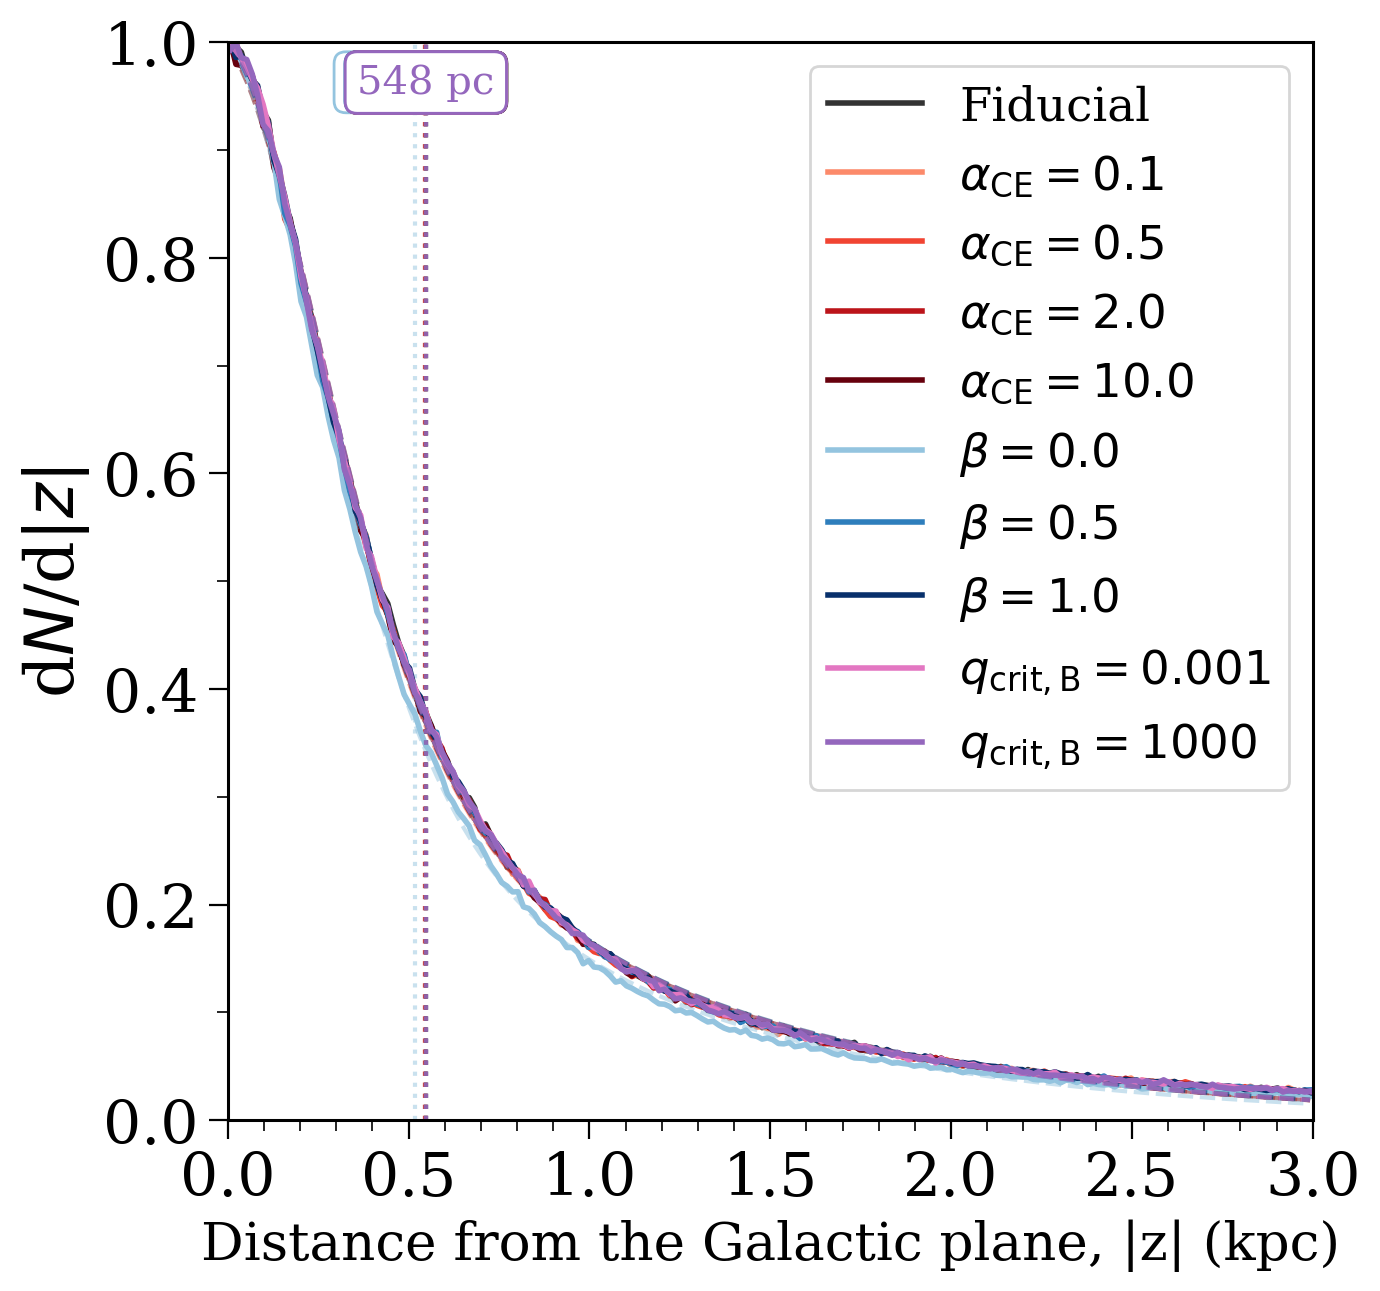

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

for pop in pops:
    scale_height, _, _, _ = plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=0.98
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

Inner 10 kpc
  Fiducial fraction within 0.5 kpc 0.48
  $\alpha_{\rm CE} = 0.1$ fraction within 0.5 kpc 0.47
  $\alpha_{\rm CE} = 0.5$ fraction within 0.5 kpc 0.48
  $\alpha_{\rm CE} = 2.0$ fraction within 0.5 kpc 0.48
  $\alpha_{\rm CE} = 10.0$ fraction within 0.5 kpc 0.49
  $\beta = 0.0$ fraction within 0.5 kpc 0.50
  $\beta = 0.5$ fraction within 0.5 kpc 0.48
  $\beta = 1.0$ fraction within 0.5 kpc 0.48


KeyError: '$q_{\\rm crit, B} = 10^{-3}$'

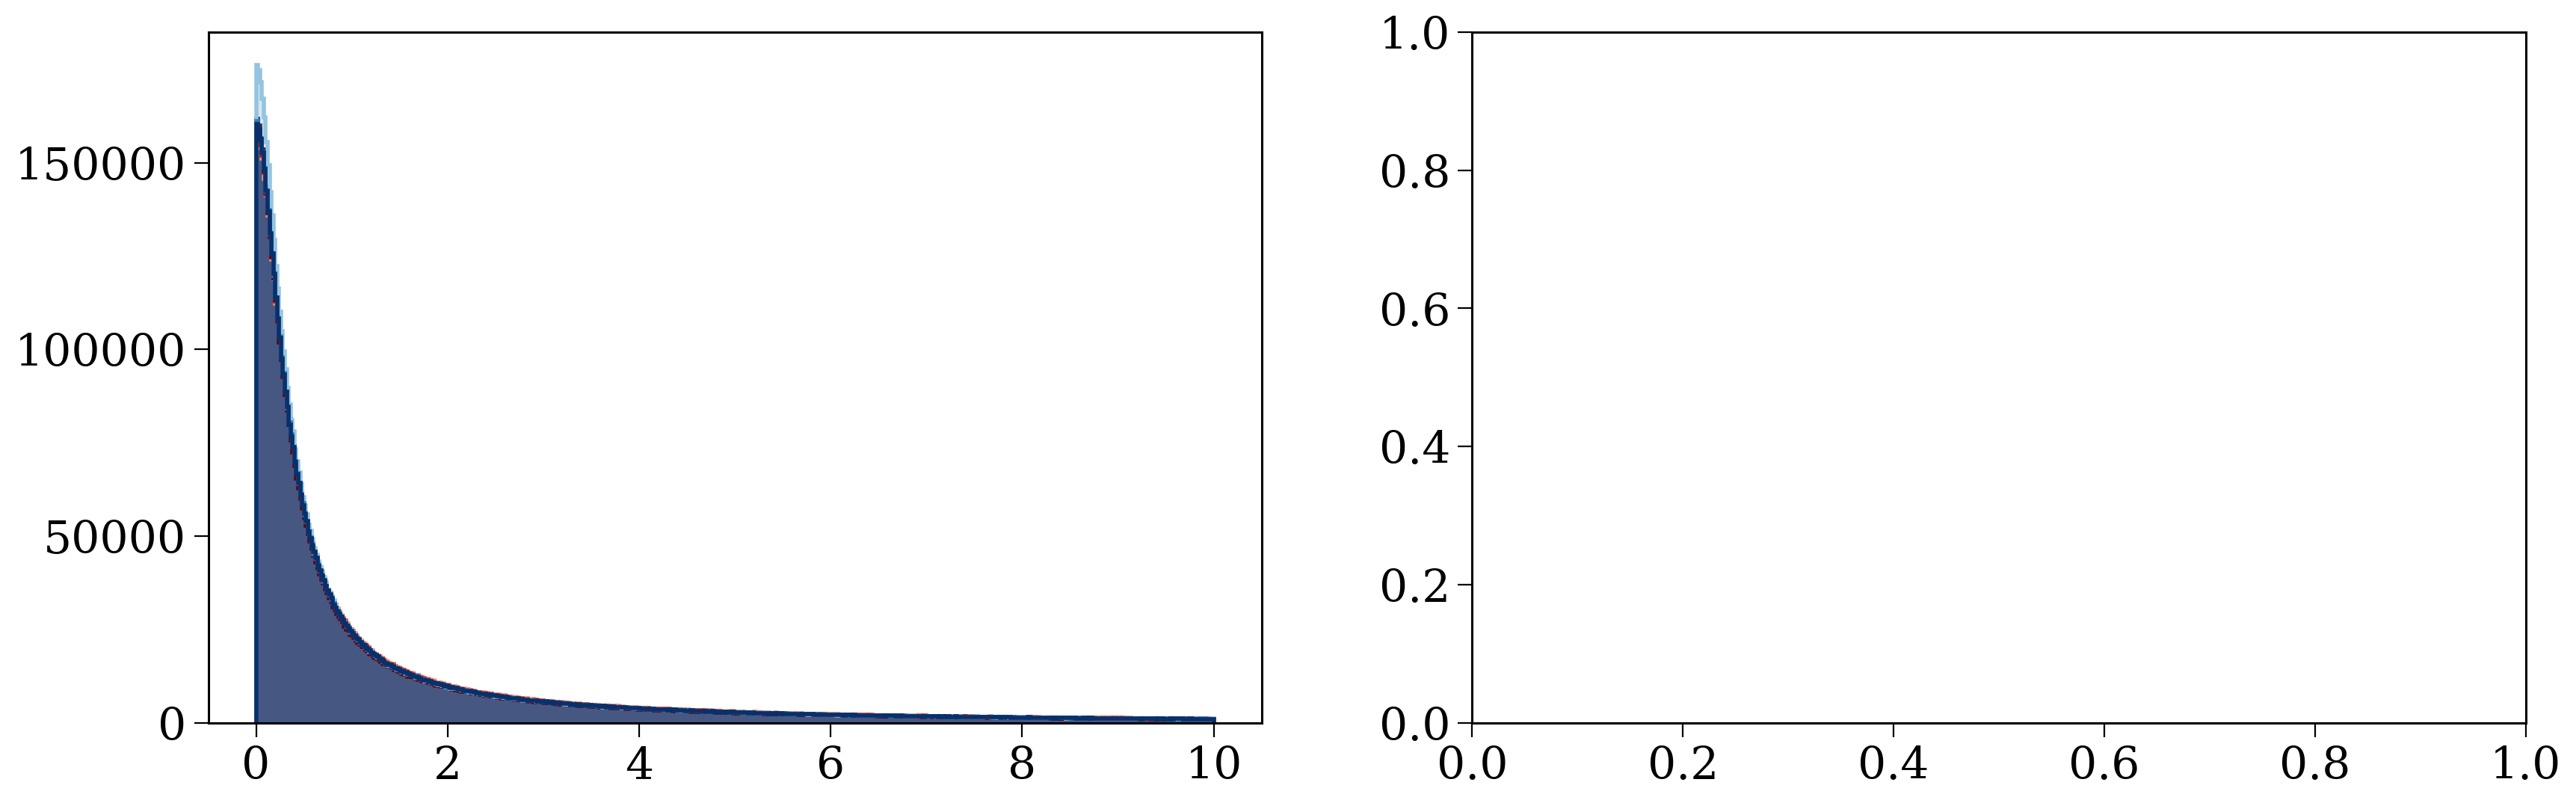

In [10]:
plotting.absolute_galactocentric_height(pops, data)

In [13]:
z_range = np.geomspace(0.1, 10, 1000)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops],
    z_range=z_range,
    window_width=0.1
)

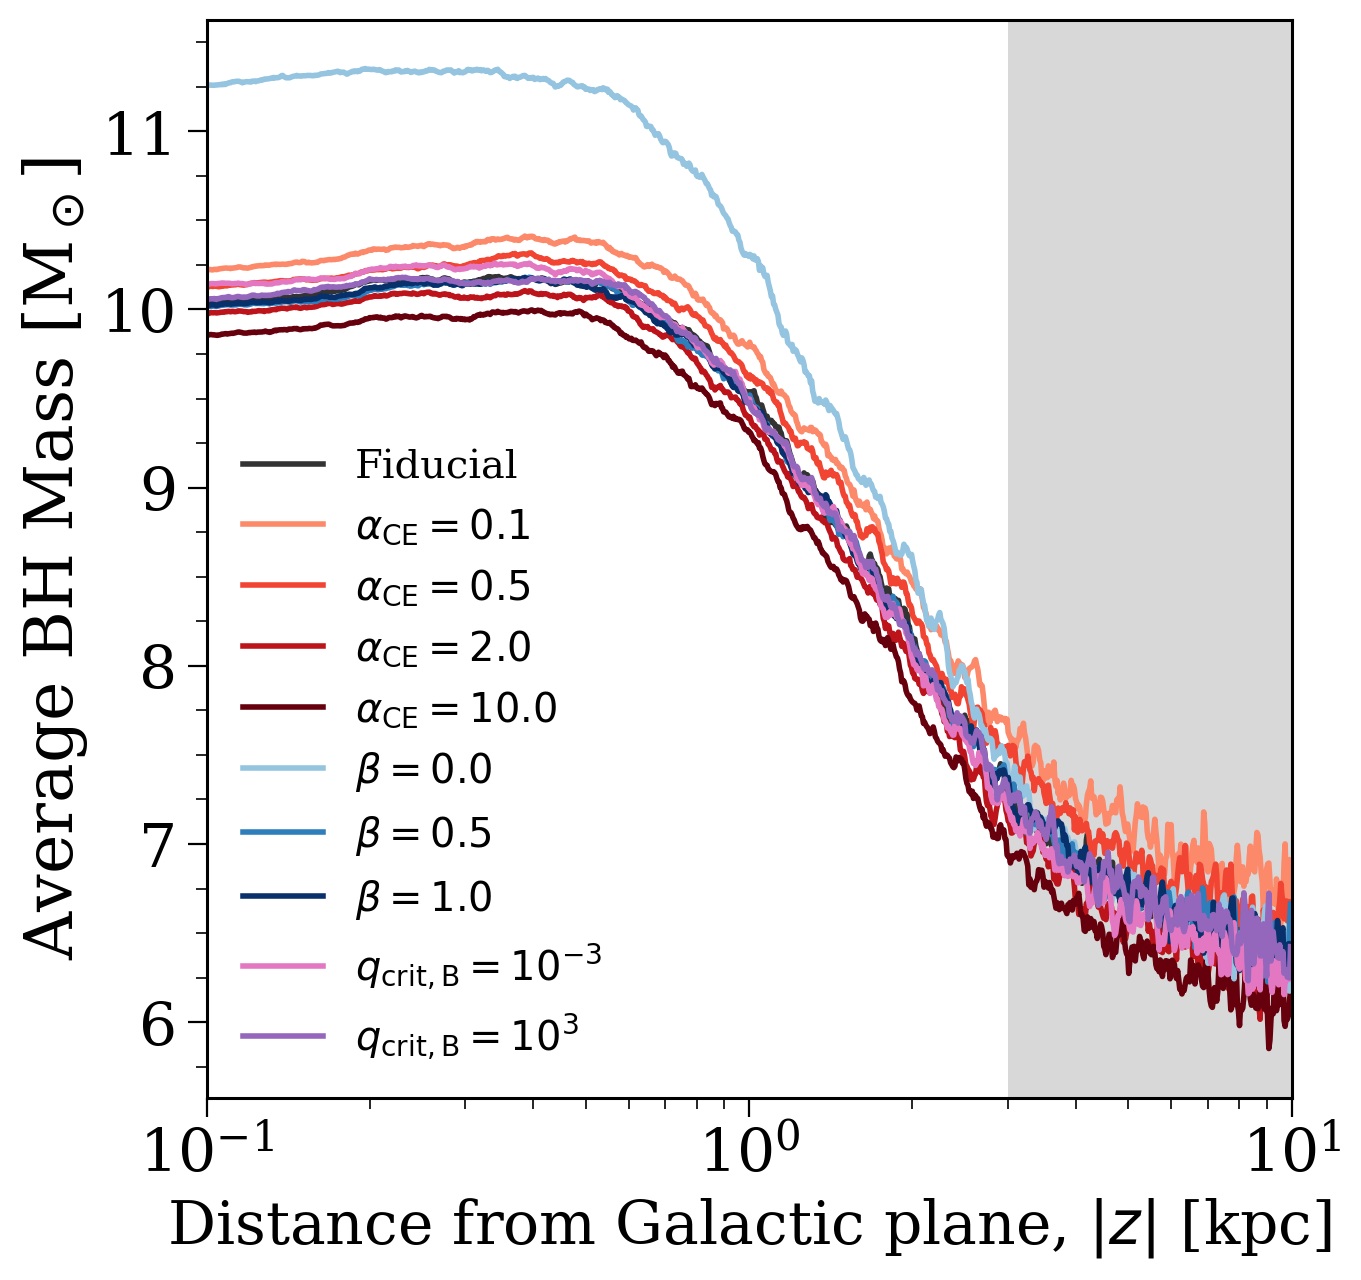

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [21]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels,
    colours=colours,
    z_maxes=[10] * len(pops),
    z_range=z_range,
    legend_kwargs={
        "loc": "lower left",
        "title": None,
        "fontsize": 0.6*fs,
        "frameon": False
    },
    save="../plots/average_bh_mass_vs_z_mt.pdf"
)

In [ ]:
bns_mergers = np.zeros(len(pops))

for i, pop in enumerate(pops):

    bns_binary = (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14) & (pop.bpp["sep"] > 0.0)
    bns_binary_nums = pop.bpp[bns_binary]["bin_num"].values

    merged_at_present_nums = pop.bin_nums[pop.final_bpp["sep"] == 0.0]

    bns_merger_nums = np.intersect1d(bns_binary_nums, merged_at_present_nums)
    bns_mergers[i] = len(bns_merger_nums)
    print(f"{pop.label}: Number of BNS mergers at present: {len(bns_merger_nums)}")

Fiducial: Number of BNS mergers at present: 287
$\alpha_{\rm CE} = 0.0$: Number of BNS mergers at present: 0
$\alpha_{\rm CE} = 0.1$: Number of BNS mergers at present: 462
$\alpha_{\rm CE} = 0.5$: Number of BNS mergers at present: 277
$\alpha_{\rm CE} = 2.0$: Number of BNS mergers at present: 225
$\alpha_{\rm CE} = 10.0$: Number of BNS mergers at present: 73
$\beta = 0.0$: Number of BNS mergers at present: 375
$\beta = 0.5$: Number of BNS mergers at present: 264
$\beta = 1.0$: Number of BNS mergers at present: 285
$q_{\rm crit, B} = 10^{-3}$: Number of BNS mergers at present: 170
$q_{\rm crit, B} = 10^{3}$: Number of BNS mergers at present: 306


/tmp/ipykernel_219660/1345778857.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)
/tmp/ipykernel_219660/1345778857.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)


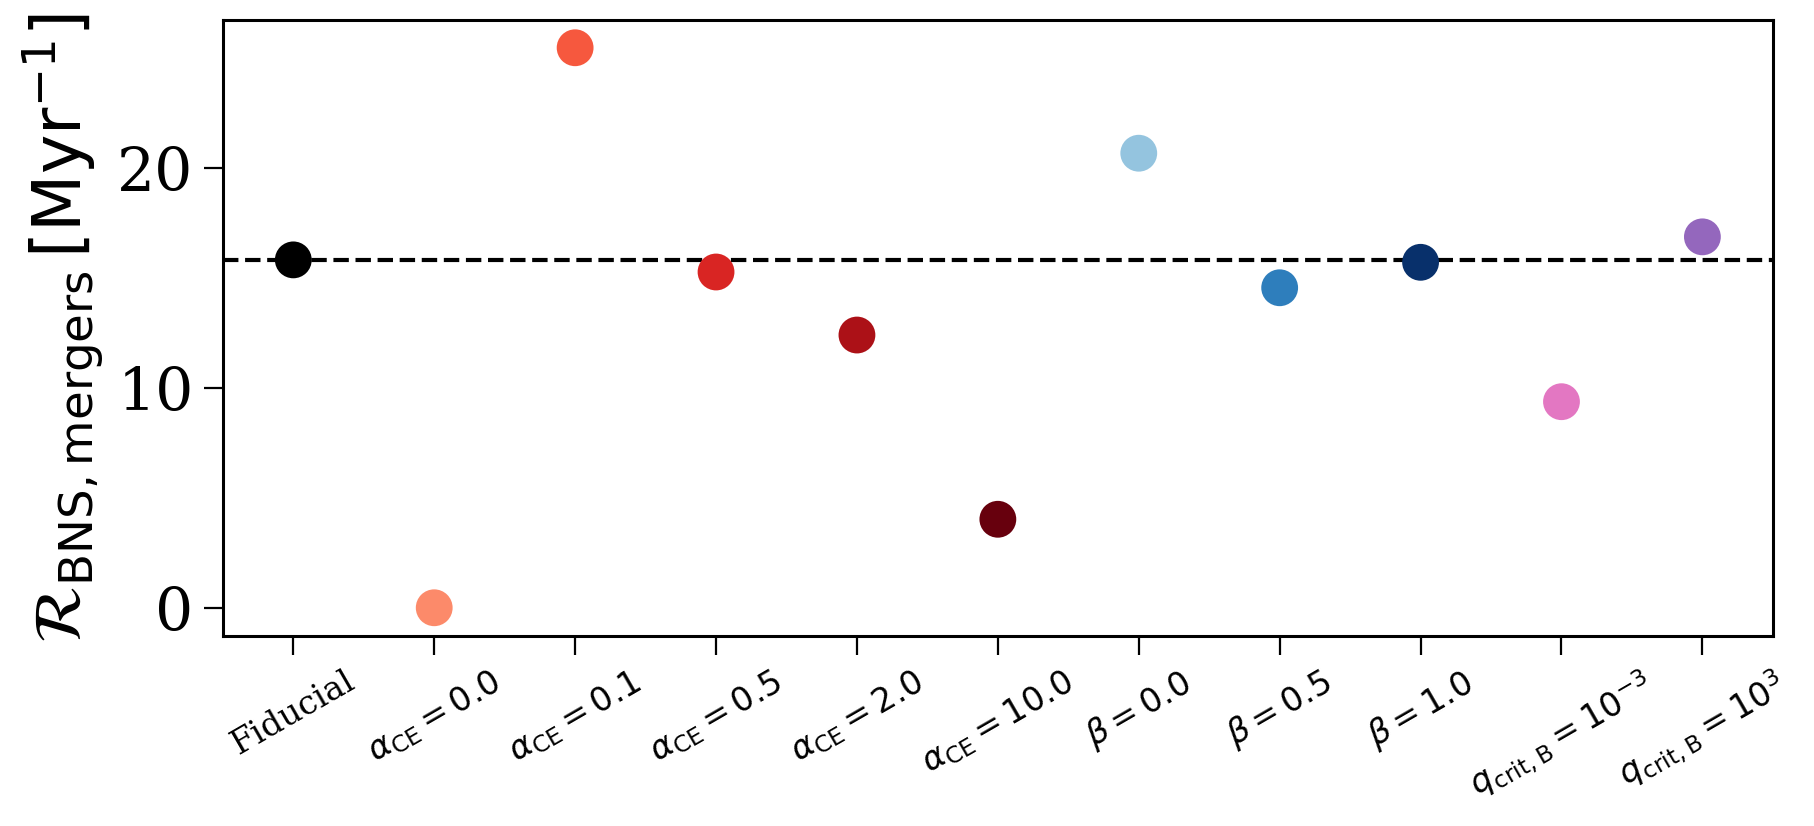

In [ ]:
labels = [pop.label for pop in pops]
colours = [pop.colour for pop in pops]

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(labels, bns_mergers * scale_up / 12000, c=colours, s=150)
ax.axhline(bns_mergers[0] * scale_up / 12000, color='black', linestyle='--', zorder=-1)
ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)
ax.set_xticklabels(labels, rotation=30, ha='center', fontsize=0.5*fs)

ax.set_ylabel("$\mathcal{R}_{\\rm{BNS, mergers}} \, [\\rm Myr^{-1}]$", fontsize=fs)

# ax.set_yticks([0, 50000, 100000, 150000, 200000, 250000, 300000])
# ax.set_yticklabels([0, 50000, 100000, 150000, 200000, 250000, 300000])

# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(25000))

plt.show()